# Part II - Ford GoBike Usage Patterns
## by Massimiliano Sermi

## Investigation Overview


This presentation explores how Ford GoBike is used across different
user groups and time periods.

The goal is to identify:
- Who uses the service most frequently.
- When bikes are most commonly used.
- How ride duration differs between Subscribers and Customers.

Key Insights:
1. Subscribers represent the majority of rides.
2. Bike usage peaks during weekday commuting hours.
3. Customers tend to take longer rides than Subscribers.



## Dataset Overview and Executive Summary

The dataset contains Ford GoBike trip records from February 2019.

Variables include:
- Ride duration
- Start and end times
- User type
- Rider demographics

After cleaning:
- Invalid birth years were removed.
- Ages were calculated from birth year.
- Datetime features such as weekday and hour were extracted.

Executive Summary

1. Subscribers account for most trips.
2. Activity is concentrated during commuting hours.
3. Customers have significantly longer ride durations,
   suggesting more recreational use.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore")

plt.style.use('default')


In [6]:
# load in the dataset into a pandas dataframe
df = pd.read_csv('201902-fordgobike-tripdata (1).csv')
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [7]:
# Data preparation

df['duration_min'] = df['duration_sec'] / 60

df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time'] = pd.to_datetime(df['end_time'])

df['start_hour'] = df['start_time'].dt.hour
df['weekday'] = df['start_time'].dt.day_name()

df['member_age'] = 2019 - df['member_birth_year']

df = df[df['member_age'] <= 80]

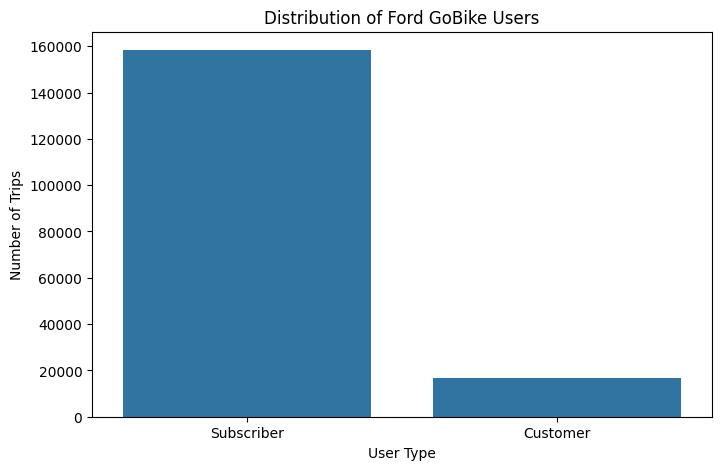

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='user_type',
    order=df['user_type'].value_counts().index
)

plt.title('Distribution of Ford GoBike Users')
plt.xlabel('User Type')
plt.ylabel('Number of Trips')

plt.show()

### Observation

Subscribers account for the vast majority of rides. This suggests that Ford GoBike is primarily used by recurring members rather than occasional customers.

## Visualization 1
### User Type Distribution



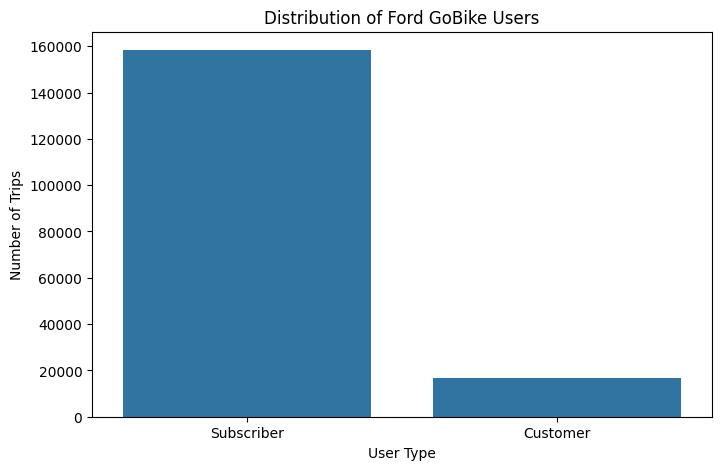

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='user_type',
    order=df['user_type'].value_counts().index
)

plt.title('Distribution of Ford GoBike Users')
plt.xlabel('User Type')
plt.ylabel('Number of Trips')

plt.show()

## Observation

Subscribers account for the vast majority of rides. This suggests that Ford GoBike is primarily used by recurring members rather than occasional customers.

## Visualization 2
### Weekday and Hour Usage Pattern


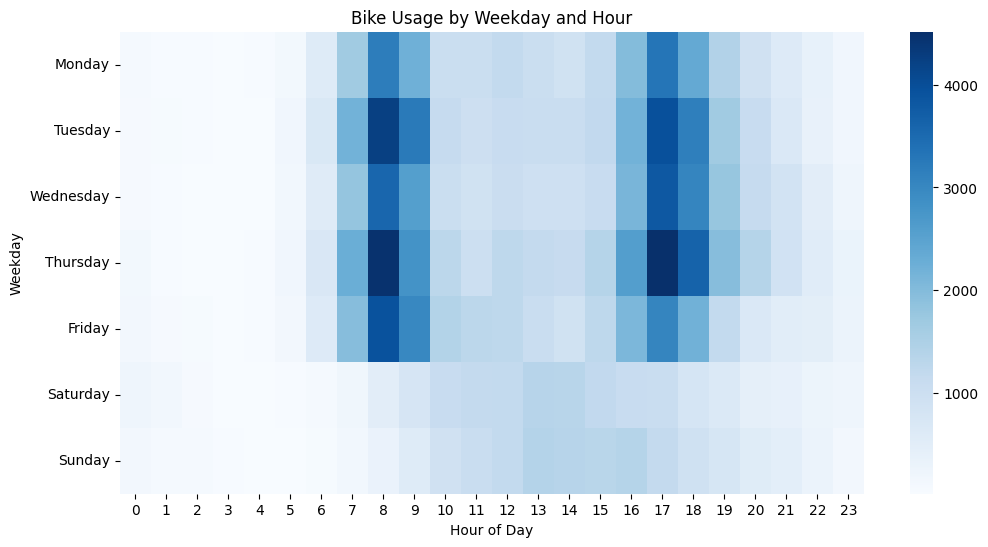

In [10]:
heatmap_data = (
    df.groupby(['weekday', 'start_hour'], observed=False)
      .size()
      .reset_index(name='count')
      .pivot(index='weekday',
             columns='start_hour',
             values='count')
)

weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

heatmap_data = heatmap_data.reindex(weekday_order)

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    cmap='Blues'
)

plt.title('Bike Usage by Weekday and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Weekday')

plt.show()

## Observation

Usage peaks during weekday mornings and evenings, matching typical commuting hours. Weekend activity is more evenly distributed throughout the day.

## Visualization 3
### Ride Duration by User Type



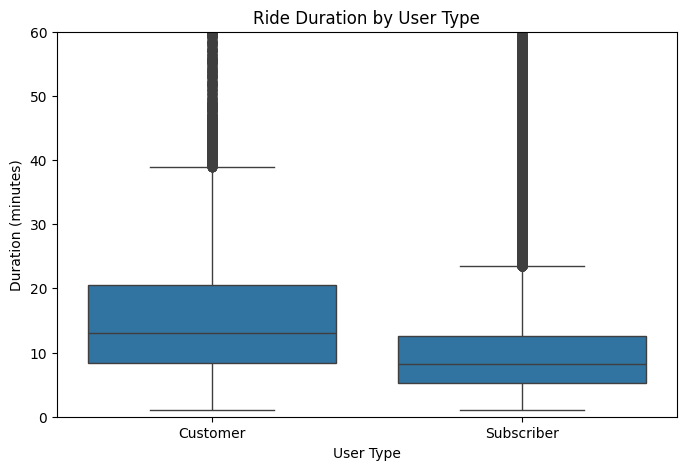

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='user_type',
    y='duration_min'
)

plt.ylim(0, 60)

plt.title('Ride Duration by User Type')
plt.xlabel('User Type')
plt.ylabel('Duration (minutes)')

plt.show()

## Observation

Customers generally take longer rides than Subscribers. This indicates that Customers are more likely to use the service for leisure or recreational trips, while Subscribers use it for shorter, practical journeys.


# Conclusions

1. Subscribers generate most of the platform activity.
2. Ride demand follows a clear weekday commuting pattern.
3. Customers take longer trips than Subscribers.

Overall, the findings suggest that Ford GoBike serves two
different usage behaviors:

- Subscribers use the service mainly for commuting.
- Customers use the service more recreationally.
